In [83]:
# Imports

from sklearn import svm
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [84]:
# Loading Dataset

dataset = pd.read_csv("Breast Cancer Wisconsin (Diagnostic).csv")
dataset. shape

(569, 33)

In [85]:
# understanding dataset

dataset.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [86]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [87]:
# Splitting Independent af=nd Dependent Features
dataset = dataset.drop("Unnamed: 32", axis = 1)
X = dataset.iloc[ : , 2:]
y = dataset.iloc[ : , 1]

In [88]:
X.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [89]:
y.head()

0    M
1    M
2    M
3    M
4    M
Name: diagnosis, dtype: object

In [90]:
y = y.map({"B": 0, "M": 1})

In [91]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

In [92]:
# Train Test Split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state =0)

In [93]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [94]:
# SVM MODEL

from sklearn.svm import SVC

svm_model = SVC(kernel = 'rbf', C=30, gamma = "auto") 
svm_model.fit(X_train_scaled, y_train)
svm_model.score(X_test_scaled,y_test)

0.9532163742690059

In [95]:
# GridSearchCV

from sklearn.model_selection import GridSearchCV
grid_model = GridSearchCV(SVC(gamma = "auto"),{
    
    "C" : np.arange(1,30,5),
    "kernel" :["rbf","linear"]
    }, cv =5, return_train_score = False)


In [96]:
grid_model.fit(X_train_scaled,y_train)

GridSearchCV(cv=5, estimator=SVC(gamma='auto'),
             param_grid={'C': array([ 1,  6, 11, 16, 21, 26]),
                         'kernel': ['rbf', 'linear']})

In [97]:
# Getting the dataframe of the results of the grid search

CV_results = pd.DataFrame(grid_model.cv_results_)
CV_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.005713,0.000774,0.002770,0.000506,1,rbf,"{'C': 1, 'kernel': 'rbf'}",0.9875,0.9375,0.9625,0.987342,1.000000,0.974968,0.022343,2
1,0.004054,0.000409,0.001015,0.000026,1,linear,"{'C': 1, 'kernel': 'linear'}",1.0000,0.9625,0.9625,0.987342,1.000000,0.982468,0.016947,1
2,0.005251,0.000723,0.002160,0.000225,6,rbf,"{'C': 6, 'kernel': 'rbf'}",0.9875,0.9375,0.9625,0.987342,0.987342,0.972437,0.019953,5
3,0.005548,0.001726,0.001405,0.000498,6,linear,"{'C': 6, 'kernel': 'linear'}",0.9875,0.9500,0.9500,1.000000,0.987342,0.974968,0.020898,2
4,0.005072,0.000937,0.003015,0.000331,11,rbf,"{'C': 11, 'kernel': 'rbf'}",0.9875,0.9375,0.9500,0.987342,0.974684,0.967405,0.020256,6
5,0.006604,0.001494,0.001294,0.000398,11,linear,"{'C': 11, 'kernel': 'linear'}",0.9750,0.9500,0.9500,1.000000,0.987342,0.972468,0.019976,4
6,0.004752,0.000779,0.002436,0.000476,16,rbf,"{'C': 16, 'kernel': 'rbf'}",0.9875,0.9375,0.9375,0.987342,0.962025,0.962373,0.022326,7
7,0.006819,0.002455,0.001821,0.000429,16,linear,"{'C': 16, 'kernel': 'linear'}",0.9750,0.9250,0.9125,1.000000,0.987342,0.959968,0.034796,8
8,0.004924,0.000666,0.002446,0.000482,21,rbf,"{'C': 21, 'kernel': 'rbf'}",0.9875,0.9375,0.9375,0.987342,0.949367,0.959842,0.022931,9
9,0.006681,0.002925,0.000991,0.000017,21,linear,"{'C': 21, 'kernel': 'linear'}",0.9625,0.9250,0.9125,1.000000,0.974684,0.954937,0.032171,11


In [98]:
# getting only the Parameters C, kernel and mean score

CV_results[["param_C","param_kernel","mean_test_score"]]

,param_C,param_kernel,mean_test_score
0,1,rbf,0.974968
1,1,linear,0.982468
2,6,rbf,0.972437
3,6,linear,0.974968
4,11,rbf,0.967405
5,11,linear,0.972468
6,16,rbf,0.962373
7,16,linear,0.959968
8,21,rbf,0.959842
9,21,linear,0.954937


In [99]:
#dir(grid_model)

In [100]:
# Finding best parameters

grid_model.best_params_

{'C': 1, 'kernel': 'linear'}

In [101]:
# Finding best scores

grid_model.best_score_

0.9824683544303797

In [102]:
# RANDOMIZED SEARCH CV because Grid Search CV is computationally costly when we use range of values for the parameters

# GridSearchCV

from sklearn.model_selection import RandomizedSearchCV
random_model = RandomizedSearchCV(SVC(gamma = "auto"),{
    
    "C" : np.arange(1,30,5),
    "kernel" :["rbf","linear"]
    }, cv =5, return_train_score = False)




In [103]:
random_model.fit(X_train_scaled,y_train)

RandomizedSearchCV(cv=5, estimator=SVC(gamma='auto'),
                   param_distributions={'C': array([ 1,  6, 11, 16, 21, 26]),
                                        'kernel': ['rbf', 'linear']})

In [104]:
# Getting the dataframe of the results of the grid search

RS_CV_results = pd.DataFrame(random_model.cv_results_)
RS_CV_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_kernel,param_C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.007384,0.001921,0.001750,0.000404,linear,26,"{'kernel': 'linear', 'C': 26}",0.9500,0.9250,0.9125,1.000000,0.987342,0.954968,0.034065,8
1,0.005227,0.000487,0.002771,0.000759,rbf,1,"{'kernel': 'rbf', 'C': 1}",0.9875,0.9375,0.9625,0.987342,1.000000,0.974968,0.022343,2
2,0.005623,0.000938,0.002625,0.000511,rbf,6,"{'kernel': 'rbf', 'C': 6}",0.9875,0.9375,0.9625,0.987342,0.987342,0.972437,0.019953,5
3,0.004239,0.000485,0.001279,0.000537,linear,1,"{'kernel': 'linear', 'C': 1}",1.0000,0.9625,0.9625,0.987342,1.000000,0.982468,0.016947,1
4,0.005287,0.001741,0.001840,0.000426,linear,6,"{'kernel': 'linear', 'C': 6}",0.9875,0.9500,0.9500,1.000000,0.987342,0.974968,0.020898,2
5,0.004754,0.000356,0.002129,0.000493,rbf,11,"{'kernel': 'rbf', 'C': 11}",0.9875,0.9375,0.9500,0.987342,0.974684,0.967405,0.020256,6
6,0.006169,0.002268,0.001309,0.000404,linear,21,"{'kernel': 'linear', 'C': 21}",0.9625,0.9250,0.9125,1.000000,0.974684,0.954937,0.032171,9
7,0.006245,0.002034,0.001219,0.000391,linear,11,"{'kernel': 'linear', 'C': 11}",0.9750,0.9500,0.9500,1.000000,0.987342,0.972468,0.019976,4
8,0.006116,0.002515,0.001522,0.000437,linear,16,"{'kernel': 'linear', 'C': 16}",0.9750,0.9250,0.9125,1.000000,0.987342,0.959968,0.034796,7
9,0.005431,0.000423,0.002119,0.000465,rbf,26,"{'kernel': 'rbf', 'C': 26}",0.9875,0.9375,0.9250,0.987342,0.936709,0.954810,0.026992,10


In [105]:
# getting only the Parameters C, kernel and mean score

RS_CV_results[["param_C","param_kernel","mean_test_score"]]

,param_C,param_kernel,mean_test_score
0,26,linear,0.954968
1,1,rbf,0.974968
2,6,rbf,0.972437
3,1,linear,0.982468
4,6,linear,0.974968
5,11,rbf,0.967405
6,21,linear,0.954937
7,11,linear,0.972468
8,16,linear,0.959968
9,26,rbf,0.954810


In [106]:
# Finding best parameters

random_model.best_params_

{'kernel': 'linear', 'C': 1}

In [107]:
# Finding best scores

random_model.best_score_

0.9824683544303797

In [108]:
# CHOOSING BEST MODEL FOR THE DATATSET


In [109]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import loguniform, randint

In [110]:
lr = LogisticRegression(max_iter=1000)

rs_lr = RandomizedSearchCV(
    estimator=lr,
    param_distributions={
    "C": loguniform(1e-3, 1e2),
    "penalty": ["l2"],
    "solver": ["lbfgs"]},
    n_iter=30,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=42)

rs_lr.fit(X_train_scaled, y_train)


RandomizedSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_iter=30,
                   n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001C963699250>,
                                        'penalty': ['l2'],
                                        'solver': ['lbfgs']},
                   random_state=42, scoring='f1')

In [111]:
svm = SVC()

rs_svm = RandomizedSearchCV(
    estimator=svm,
    param_distributions={
    "C": loguniform(1e-2, 1e3),
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]},
    n_iter=30,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=42
)

rs_svm.fit(X_train_scaled, y_train)


RandomizedSearchCV(cv=5, estimator=SVC(), n_iter=30, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001C96006F350>,
                                        'gamma': ['scale', 'auto'],
                                        'kernel': ['linear', 'rbf']},
                   random_state=42, scoring='f1')

In [112]:
rf = RandomForestClassifier(random_state=42)

rs_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=
    {
    "n_estimators": randint(50, 300),
    "max_depth": randint(2, 15),
    "min_samples_split": randint(2, 10)},
    n_iter=30,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=42
)

rs_rf.fit(X_train, y_train)


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001C962F16490>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001C962F55410>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001C962ED4F10>},
                   random_state=42, scoring='f1')

In [113]:
print(f"Logistic Regression: {rs_lr.best_score_}")
print(f"SVM: {rs_svm.best_score_}")
print(f"Random Forest: {rs_rf.best_score_}")


Logistic Regression: 0.9794171870353849
SVM: 0.9796376186367558
Random Forest: 0.9423455866866292


In [114]:
best_model_name = max(scores, key=scores.get)

best_model = {
    "Logistic Regression": rs_lr.best_estimator_,
    "SVM": rs_svm.best_estimator_,
    "Random Forest": rs_rf.best_estimator_
}[best_model_name]

best_model_name


'Logistic Regression'

In [115]:
if best_model_name in ["Logistic Regression", "SVM"]:
    y_pred = best_model.predict(X_test_scaled)
else:
    y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.97      0.99      0.98       108
           1       0.98      0.95      0.97        63

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



In [117]:
from sklearn.metrics import ConfusionMatrixDisplay

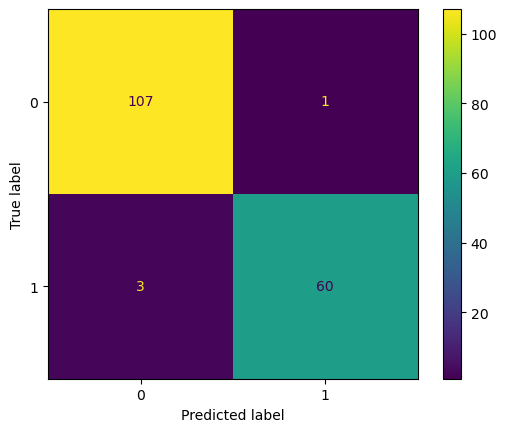

In [119]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)